# Monty Hall Simulation Analysis

This notebook analyzes the output produced by `simulator.py`.

Expected project structure:

```text
monty-hall/
├── game.py
├── simulator.py
├── analysis.ipynb
├── results.csv
└── README.md
```

The simulator is expected to write:

```text
Iteration,Swapped?,Win
```

This notebook will:

1. Load and validate the simulation results.
2. Show a preview of the data.
3. Build a summary table for the keep and swap strategies.
4. Graph the final win rates.
5. Graph cumulative wins.
6. Graph running win rate over time.
7. Optionally save all graphs as PNG files.


## 1. Imports and configuration

In [10]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

RESULTS_FILE = Path("results.csv")


## 2. Load the results

In [11]:
if not RESULTS_FILE.exists():
    raise FileNotFoundError(
        f"Could not find {RESULTS_FILE}. "
        "Run simulator.py first and make sure results.csv is in the same folder as this notebook."
    )

df = pd.read_csv(RESULTS_FILE)
df.head()


,Iteration,Swapped?,Win
0,1,False,True
1,2,False,True
2,3,False,True
3,4,False,False
4,5,False,False


## 3. Validate and clean the data

The notebook expects three columns:

- `Iteration`
- `Swapped?`
- `Win`

The conversion below also makes the notebook robust if the boolean columns are loaded as strings.


In [12]:
expected_columns = {"Iteration", "Swapped?", "Win"}
missing_columns = expected_columns - set(df.columns)

if missing_columns:
    raise ValueError(f"Missing expected columns: {sorted(missing_columns)}")

def to_bool(series):
    if series.dtype == bool:
        return series

    mapping = {
        "true": True,
        "false": False,
        "1": True,
        "0": False,
    }

    converted = series.astype(str).str.strip().str.lower().map(mapping)

    if converted.isna().any():
        bad_values = series[converted.isna()].unique()
        raise ValueError(f"Could not interpret boolean values: {bad_values}")

    return converted

df["Swapped?"] = to_bool(df["Swapped?"])
df["Win"] = to_bool(df["Win"])
df = df.sort_values("Iteration").reset_index(drop=True)

df.dtypes


Iteration    int64
Swapped?      bool
Win           bool
dtype: object

## 4. Preview the simulation data

Each row represents one simulated game.


In [13]:
df.head(10)


,Iteration,Swapped?,Win
0,1,False,True
1,2,False,True
2,3,False,True
3,4,False,False
4,5,False,False
5,6,False,False
6,7,False,False
7,8,False,False
8,9,False,True
9,10,False,True


## 5. Summary table

In [14]:
summary = (
    df.groupby("Swapped?")["Win"]
      .agg(Games="size", Wins="sum")
      .reset_index()
)

summary["Losses"] = summary["Games"] - summary["Wins"]
summary["Win Rate (%)"] = (summary["Wins"] / summary["Games"] * 100).round(2)

summary["Strategy"] = summary["Swapped?"].map({
    False: "Kept choice",
    True: "Swapped",
})

summary = summary[
    ["Strategy", "Games", "Wins", "Losses", "Win Rate (%)"]
]

summary


,Strategy,Games,Wins,Losses,Win Rate (%)
0,Kept choice,499,160,339,32.06
1,Swapped,501,321,180,64.07


## 6. Final win-rate comparison

This chart compares the final observed win percentage for the two strategies.


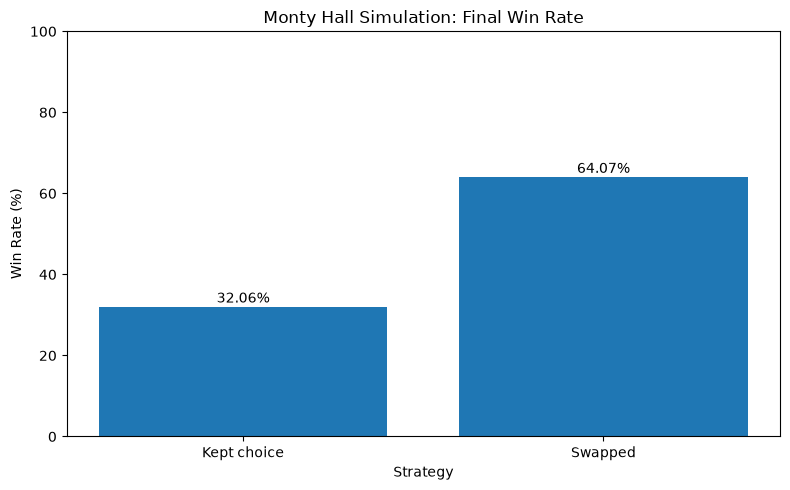

In [15]:
plt.figure(figsize=(8, 5))

plt.bar(
    summary["Strategy"],
    summary["Win Rate (%)"],
)

plt.ylabel("Win Rate (%)")
plt.xlabel("Strategy")
plt.title("Monty Hall Simulation: Final Win Rate")
plt.ylim(0, 100)

for index, value in enumerate(summary["Win Rate (%)"]):
    plt.text(index, value + 1, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.show()


## 7. Cumulative wins

This is the direct enumeration-style view: one line tracks how many total wins the keep strategy has accumulated, while the other tracks the swap strategy.

Because the simulator may run all keep games first and all swap games second, the two groups are reset to their own internal game numbers before plotting.


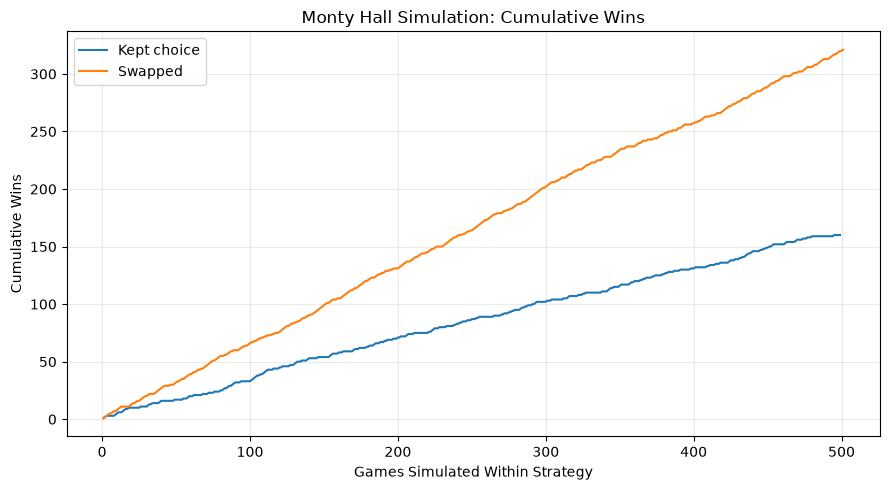

In [16]:
keepers = df[df["Swapped?"] == False].reset_index(drop=True).copy()
swappers = df[df["Swapped?"] == True].reset_index(drop=True).copy()

keepers["Game Number"] = keepers.index + 1
swappers["Game Number"] = swappers.index + 1

keepers["Cumulative Wins"] = keepers["Win"].cumsum()
swappers["Cumulative Wins"] = swappers["Win"].cumsum()

plt.figure(figsize=(9, 5))

plt.plot(
    keepers["Game Number"],
    keepers["Cumulative Wins"],
    label="Kept choice",
)

plt.plot(
    swappers["Game Number"],
    swappers["Cumulative Wins"],
    label="Swapped",
)

plt.xlabel("Games Simulated Within Strategy")
plt.ylabel("Cumulative Wins")
plt.title("Monty Hall Simulation: Cumulative Wins")
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()


## 8. Running win rate

Cumulative wins show the raw totals, but running win rate is usually the clearer strategy comparison.

For each strategy, the first point is the win rate after one game, the second is the win rate after two games, and so on.


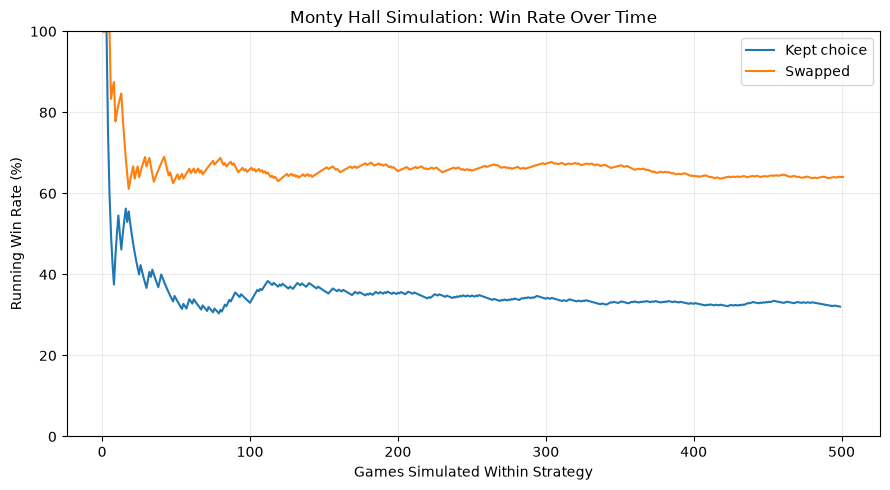

In [17]:
keepers["Running Win Rate (%)"] = keepers["Win"].expanding().mean() * 100
swappers["Running Win Rate (%)"] = swappers["Win"].expanding().mean() * 100

plt.figure(figsize=(9, 5))

plt.plot(
    keepers["Game Number"],
    keepers["Running Win Rate (%)"],
    label="Kept choice",
)

plt.plot(
    swappers["Game Number"],
    swappers["Running Win Rate (%)"],
    label="Swapped",
)

plt.xlabel("Games Simulated Within Strategy")
plt.ylabel("Running Win Rate (%)")
plt.title("Monty Hall Simulation: Win Rate Over Time")
plt.ylim(0, 100)
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()


## 9. Optional: save the figures

Run this cell if you want PNG copies of all three charts for a README or report. They will be saved in a `plots/` directory.


In [18]:
PLOTS_DIR = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)

# Final win-rate bar chart
plt.figure(figsize=(8, 5))
plt.bar(summary["Strategy"], summary["Win Rate (%)"])
plt.ylabel("Win Rate (%)")
plt.xlabel("Strategy")
plt.title("Monty Hall Simulation: Final Win Rate")
plt.ylim(0, 100)

for index, value in enumerate(summary["Win Rate (%)"]):
    plt.text(index, value + 1, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "final_win_rates.png", dpi=300)
plt.close()

# Cumulative wins
plt.figure(figsize=(9, 5))
plt.plot(keepers["Game Number"], keepers["Cumulative Wins"], label="Kept choice")
plt.plot(swappers["Game Number"], swappers["Cumulative Wins"], label="Swapped")
plt.xlabel("Games Simulated Within Strategy")
plt.ylabel("Cumulative Wins")
plt.title("Monty Hall Simulation: Cumulative Wins")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "cumulative_wins.png", dpi=300)
plt.close()

# Running win rate
plt.figure(figsize=(9, 5))
plt.plot(keepers["Game Number"], keepers["Running Win Rate (%)"], label="Kept choice")
plt.plot(swappers["Game Number"], swappers["Running Win Rate (%)"], label="Swapped")
plt.xlabel("Games Simulated Within Strategy")
plt.ylabel("Running Win Rate (%)")
plt.title("Monty Hall Simulation: Win Rate Over Time")
plt.ylim(0, 100)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "running_win_rates.png", dpi=300)
plt.close()

print(f"Saved graphs to: {PLOTS_DIR.resolve()}")


Saved graphs to: /Users/hydeharris/Dev/small-projects/monty-hall-simulator/plots
